In [75]:
# 1. Enable automatic reloading of modified local scripts
%load_ext autoreload
%autoreload 2

import sys
import os

# This bridges the notebook to the custom /src modules
sys.path.append(os.path.abspath('.'))

print("🚀 Environment aligned! Notebook is linked to your /src architecture.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🚀 Environment aligned! Notebook is linked to your /src architecture.


## **1. Data Ingestion & Local Storage Setup**

In this section, we programmatically pull two localized datasets from Kaggle containing Philippine-context SMS spam and smishing messages:
1. `bwandowando/philippine-spam-sms-messages`
2. `scottleechua/ph-spam-marketing-sms-w-timestamps`

We leverage `kagglehub` to handle API communication. Our backend script copies these files out of the system cache into our tracking repository (`data/1_raw/`), normalizes their conflicting schemas, strips cross-over duplicate texts, and converts string classes into strict integers ($0$ for Ham, $1$ for Smishing/Spam) inside `data/2_interim/`.

In [76]:
from src.loaders.data_loader import load_and_combine_ph_data

# Triggers the automated extraction from the Kaggle Cache Matrix
df_raw = load_and_combine_ph_data()

# Render descriptive outputs directly in your log dashboard
print("\n--- Remaining Targets for Machine Learning Evaluation ---")
print(df_raw['category'].value_counts())

📥 Loading Dataset 1 (bwandowando)...
📥 Loading Dataset 2 (scottleechua)...
🏁 Data Ingestion Complete! Merged shape: (2731, 6)

--- Remaining Targets for Machine Learning Evaluation ---
category
smishing    1843
ads          752
gov          133
notifs         3
Name: count, dtype: int64


## **2. Feature Engineering & Linguistic Sanitization**
In this phase, we move beyond raw text to capture the "intent" of the sender. We define a custom `SmishingFeatureExtractor` class that performs two types of feature extraction:
* **Structural Metadata:** We quantify message length, URL presence, and temporal metadata (hour of reception).
* **Linguistic Signaling:** We map message content against a curated list of high-risk Taglish and English keywords (e.g., `nanalo`, `verify`, `premyo`). This creates an "Urgency Score" that serves as a high-signal feature for our metadata-heavy models.

In [77]:
from src.preprocessing.text_cleaner import SmishingFeatureExtractor

extractor = SmishingFeatureExtractor()
df_features = extractor.extract_meta_features(df_raw)

print("✅ Meta-features appended successfully!")
df_features[['text', 'text_len', 'has_url',
             'urgency_score', 'hour_received', 'label']].head()

✅ Meta-features appended successfully!


,text,text_len,has_url,urgency_score,hour_received,label
137,Nice! You received a P10 voucher from Maya. Us...,156,0,3,18,0
138,Nice! You received a P20 voucher from Maya. Us...,156,0,3,11,0
139,Nice! You received a P10 voucher from Maya. Us...,156,0,3,16,0
140,Nice! You received a P20 voucher from Maya. Us...,156,0,3,12,0
141,Nice! You received a P10 voucher from Maya. Us...,156,0,3,13,0


## **3. Feature Matrix Partitioning & Vectorization**

We isolate our engineered numerical features from the raw target flags ($y$). To ensure our text metrics remain untainted by validation data leakage, we partition our data arrays into training and evaluation blocks *before* extracting our text TF-IDF tokens. This ensures that the vectorizer's vocabulary is strictly derived from the training set, preventing the model from "peeking" at the evaluation data.

In [78]:
from sklearn.model_selection import train_test_split
from src.preprocessing.vectorizers import SmishingTfidfVectorizer

# 1. Isolate target variable y from your features dataframe
y = df_features['label']

# 2. Build metadata feature list from df_features
meta_columns = ["text_len", "has_url", "urgency_score", "hour_received"] + \
    [col for col in df_features.columns if col.startswith("sc_")]
X_meta = df_features[meta_columns].values
X_text_raw = df_features["text"]

# 3. Stratified Split to preserve exact class imbalances
X_text_train_raw, X_text_test_raw, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text_raw, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize and run our modular Vectorizer Layer
tfidf_handler = SmishingTfidfVectorizer(max_features=10000)
X_text_train = tfidf_handler.fit_transform(X_text_train_raw)
X_text_test = tfidf_handler.transform(X_text_test_raw)

# Save the matrix state for potential final Streamlit production integration
tfidf_handler.save_vectorizer()

print("\n--- Feature Matrix Dimensionality Verification ---")
print(
    f"X_text_train Shape: {X_text_train.shape} | X_meta_train Shape: {X_meta_train.shape}")
print(
    f"X_text_test Shape:  {X_text_test.shape}  | X_meta_test Shape:  {X_meta_test.shape}")

📦 TF-IDF Vectorizer saved to saved_models/tfidf_vectorizer.pkl

--- Feature Matrix Dimensionality Verification ---
X_text_train Shape: (2184, 10000) | X_meta_train Shape: (2184, 7)
X_text_test Shape:  (547, 10000)  | X_meta_test Shape:  (547, 7)


## **4. Base-Model Training & Hyperparameter Optimization**

In this phase, we instantiate five distinct estimators to capture different signal patterns—balancing both linguistic and structural features to maximize detection accuracy. We utilize a modular configuration dictionary to map specific algorithms to their appropriate feature sets (Textual vs. Metadata) before triggering the training backend.

--- Individual Model Performance ---
✅ SVM (Text): Complete
✅ Naive Bayes (Text): Complete
✅ Logistic Regression (Text): Complete
✅ Random Forest (Metadata): Complete
✅ XGBoost (Metadata Base): Complete


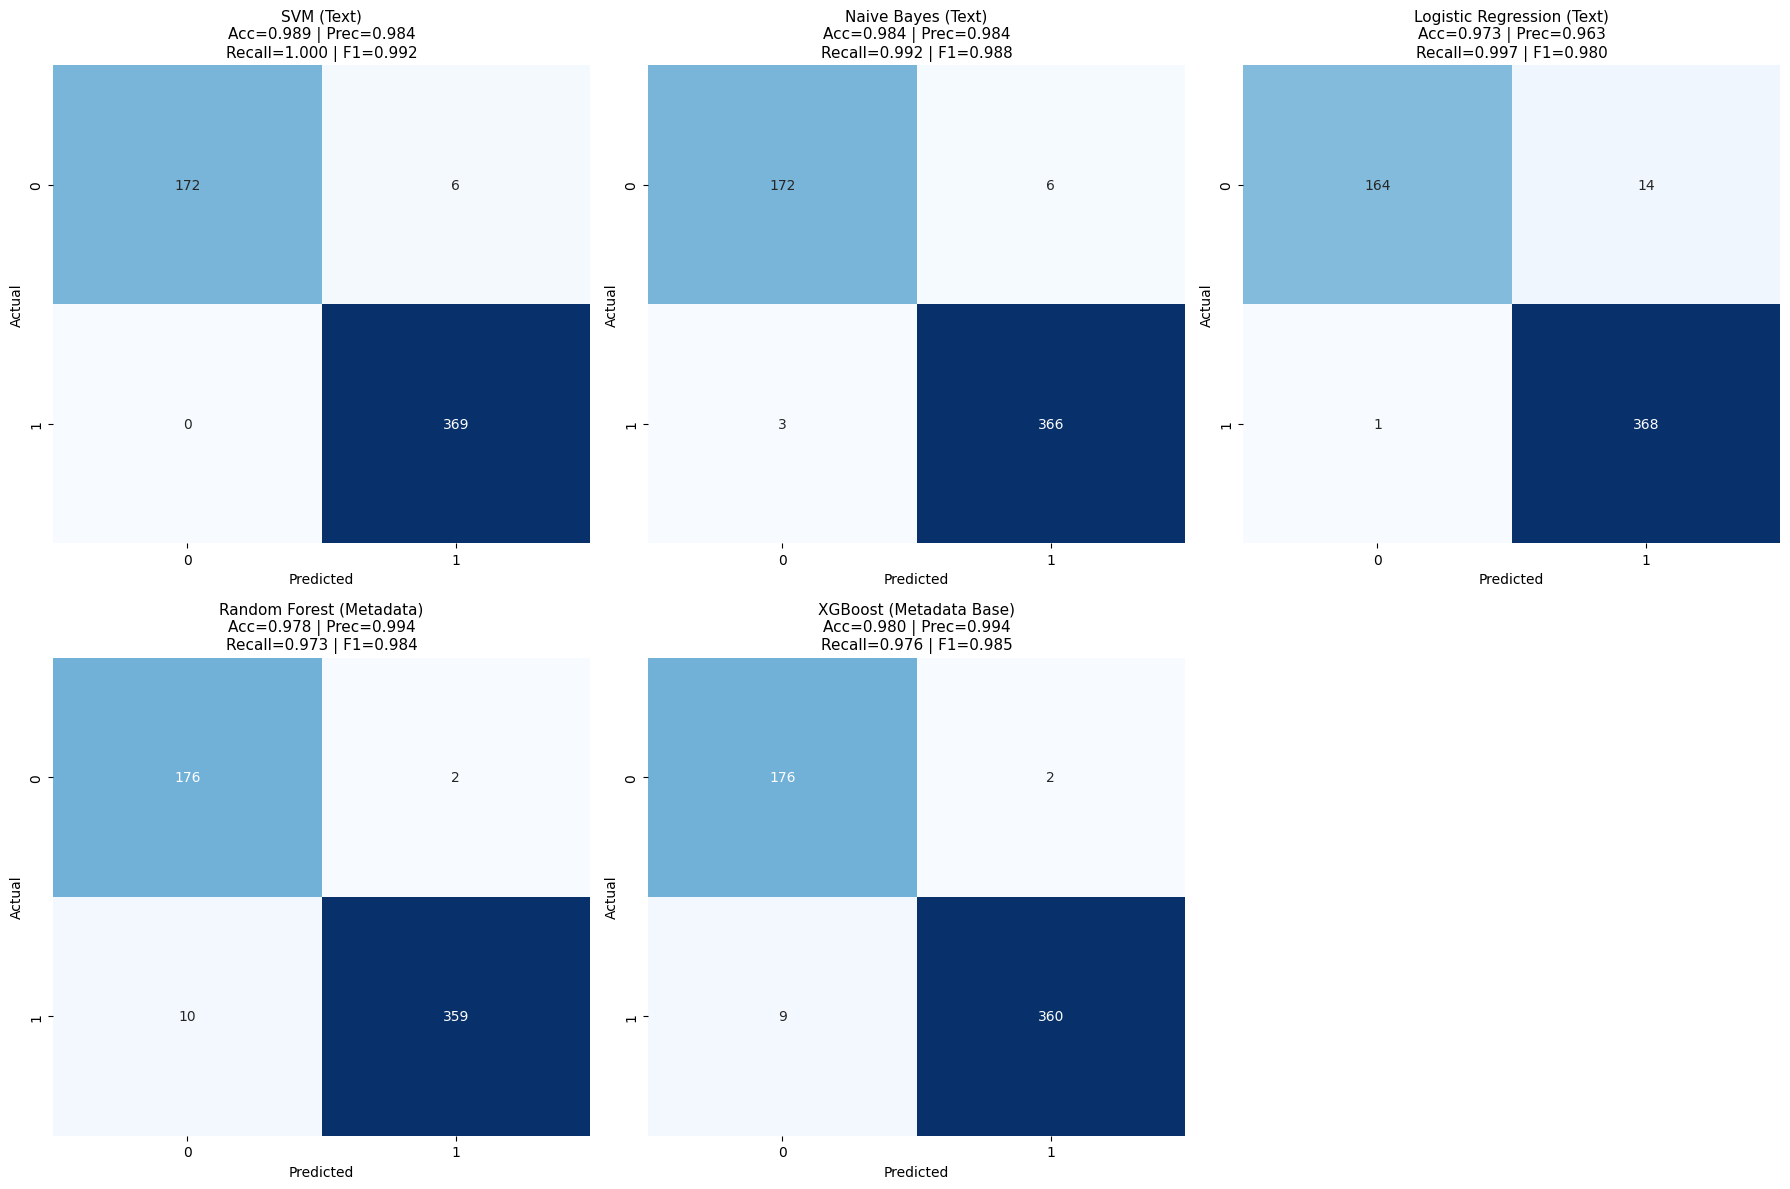


--- Final Model Performance Summary Table ---


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (Text),0.989031,0.984000,1.00000,0.991935
1,Naive Bayes (Text),0.983547,0.983871,0.99187,0.987854
2,XGBoost (Metadata Base),0.979890,0.994475,0.97561,0.984952
3,Random Forest (Metadata),0.978062,0.994460,0.97290,0.983562
4,Logistic Regression (Text),0.972578,0.963351,0.99729,0.980027


In [79]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from src.evaluation.metrics import evaluate_and_plot_models

# Define your algorithm architecture dictionaries mapping to their respective inputs
models_config = {
    "SVM (Text)": (SVC(kernel="linear", random_state=42), X_text_train, X_text_test),
    "Naive Bayes (Text)": (MultinomialNB(), X_text_train, X_text_test),
    "Logistic Regression (Text)": (LogisticRegression(max_iter=1000, random_state=42), X_text_train, X_text_test),
    "Random Forest (Metadata)": (RandomForestClassifier(n_estimators=100, random_state=42), X_meta_train, X_meta_test),
    "XGBoost (Metadata Base)": (XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42), X_meta_train, X_meta_test),
}

# Run the training loops, metric generation, and plotting backend
results_df = evaluate_and_plot_models(models_config, y_train, y_test)

print("\n--- Final Model Performance Summary Table ---")
results_df

## **5. Meta-Classifier Ensemble Orchestration**

This is the "Brain" of the system. Rather than relying on a single estimator, we perform an automated search across various stacked combinations of our base models. This orchestrator generates probability vectors from each base model, which are then treated as input features for a final meta-classifier, allowing the system to learn the optimal weightings and reliability of each model's predictions.

In [80]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from src.models.ensemble import evaluate_all_stacked_combinations

# 1. Map models to their corresponding inputs (Text or Metadata)
base_models_config = {
    "SVM": (SVC(kernel="linear", probability=True, random_state=42), X_text_train, X_text_test),
    "LR": (LogisticRegression(max_iter=1000, random_state=42), X_text_train, X_text_test),
    "NB": (MultinomialNB(), X_text_train, X_text_test),
    "RF": (RandomForestClassifier(n_estimators=100, random_state=42), X_meta_train, X_meta_test),
    "XGB_Base": (XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42), X_meta_train, X_meta_test)
}

# 2. Fire up the backend modular search engine (UNPACKING ALL 3 OUTPUTS)
stacked_results_df, train_probs, test_probs = evaluate_all_stacked_combinations(
    base_models_config, y_train, y_test
)

# 3. Output the ultimate Top 10 configurations for grading
print("\n🏆 --- Top 10 Stacked Ensemble Combinations --- 🏆")
stacked_results_df.head(10)

🔄 Generating out-of-fold base model probabilities...
  ↳ SVM: Probabilities generated.
  ↳ LR: Probabilities generated.
  ↳ NB: Probabilities generated.
  ↳ RF: Probabilities generated.
  ↳ XGB_Base: Probabilities generated.

⚔️ Evaluating all 31 stacked ensemble combinations...

🎉 All combinations evaluated successfully!

🏆 --- Top 10 Stacked Ensemble Combinations --- 🏆


,Combination,Model_Count,Accuracy,Precision,Recall,F1-Score
0,SVM + LR + NB + RF,4,0.994516,0.997283,0.99458,0.995929
1,SVM + LR + NB + RF + XGB_Base,5,0.994516,0.997283,0.99458,0.995929
2,SVM + LR + RF + XGB_Base,4,0.994516,0.997283,0.99458,0.995929
3,SVM + LR + NB + XGB_Base,4,0.994516,0.997283,0.99458,0.995929
4,SVM + LR + RF,3,0.994516,0.997283,0.99458,0.995929
5,SVM + RF + XGB_Base,3,0.994516,0.997283,0.99458,0.995929
6,SVM + XGB_Base,2,0.992687,0.994580,0.99458,0.994580
7,SVM + NB + RF,3,0.992687,0.997275,0.99187,0.994565
8,SVM + NB + XGB_Base,3,0.992687,0.997275,0.99187,0.994565
9,SVM + NB + RF + XGB_Base,4,0.992687,0.997275,0.99187,0.994565


## **6. Model Visualization & Champion Configuration**

To conclude our experimental pipeline, we visualize the optimization landscape. By plotting the F1-Score of various ensemble combinations against the number of base models utilized, we can identify the "sweet spot" where complexity meets performance. This swarm plot highlights the stability of our stacked configurations, allowing us to select the champion architecture that best balances predictive power with computational efficiency.

C:\Users\joshu\AppData\Local\Temp\ipykernel_77480\4072640900.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


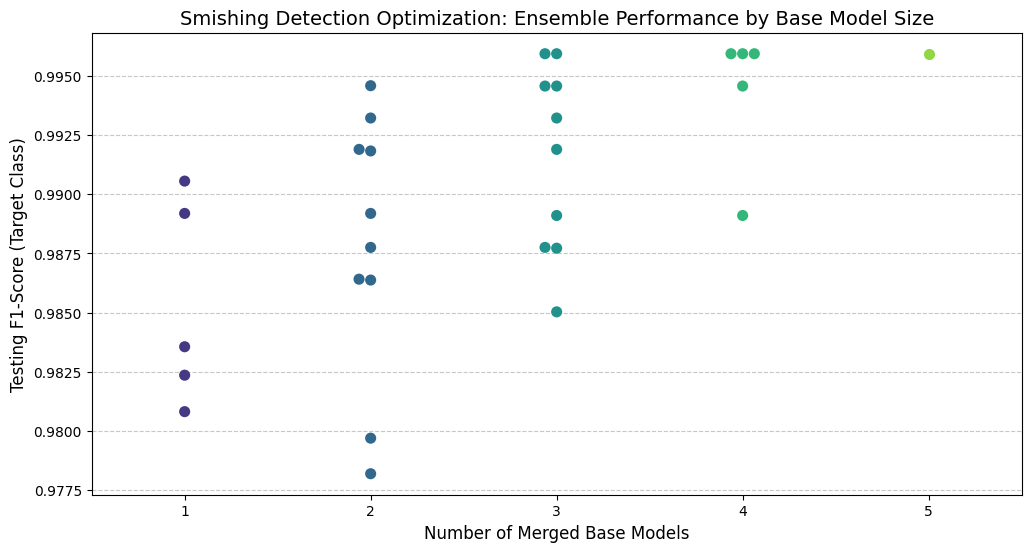

🥇 THE WINNING SYSTEM ARCHITECTURE: SVM + LR + NB + RF
🔥 Champion F1-Score: 0.9959


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Plot the F1-Score of all combinations colored by the number of models involved
sns.swarmplot(
    data=stacked_results_df,
    x="Model_Count",
    y="F1-Score",
    palette="viridis",
    size=8
)

plt.title("Smishing Detection Optimization: Ensemble Performance by Base Model Size", fontsize=14)
plt.xlabel("Number of Merged Base Models", fontsize=12)
plt.ylabel("Testing F1-Score (Target Class)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Extract and crown the master configuration
champion_combo = stacked_results_df.iloc[0]
print(f"🥇 THE WINNING SYSTEM ARCHITECTURE: {champion_combo['Combination']}")
print(f"🔥 Champion F1-Score: {champion_combo['F1-Score']:.4f}")

## **7. Ensemble Performance Diagnostic: Confusion Matrix Grid**

To validate the robustness of our champion architecture, we generate a comprehensive visualization of the ensemble’s decision-making behavior. This stage renders a side-by-side diagnostic grid comparing the predicted vs. actual classifications for the top-performing ensemble combinations. By visualizing the true positives, false positives, true negatives, and false negatives, we can assess the model's sensitivity to smishing threats versus its potential to misclassify legitimate communications (ham).

🔄 Generating out-of-fold base model probabilities...
  ↳ SVM: Probabilities generated.
  ↳ LR: Probabilities generated.
  ↳ NB: Probabilities generated.
  ↳ RF: Probabilities generated.
  ↳ XGB_Base: Probabilities generated.

⚔️ Evaluating all 31 stacked ensemble combinations...

🎉 All combinations evaluated successfully!
🔮 Generating all 31 hybrid ensemble confusion matrices (Purples Spectrum)...


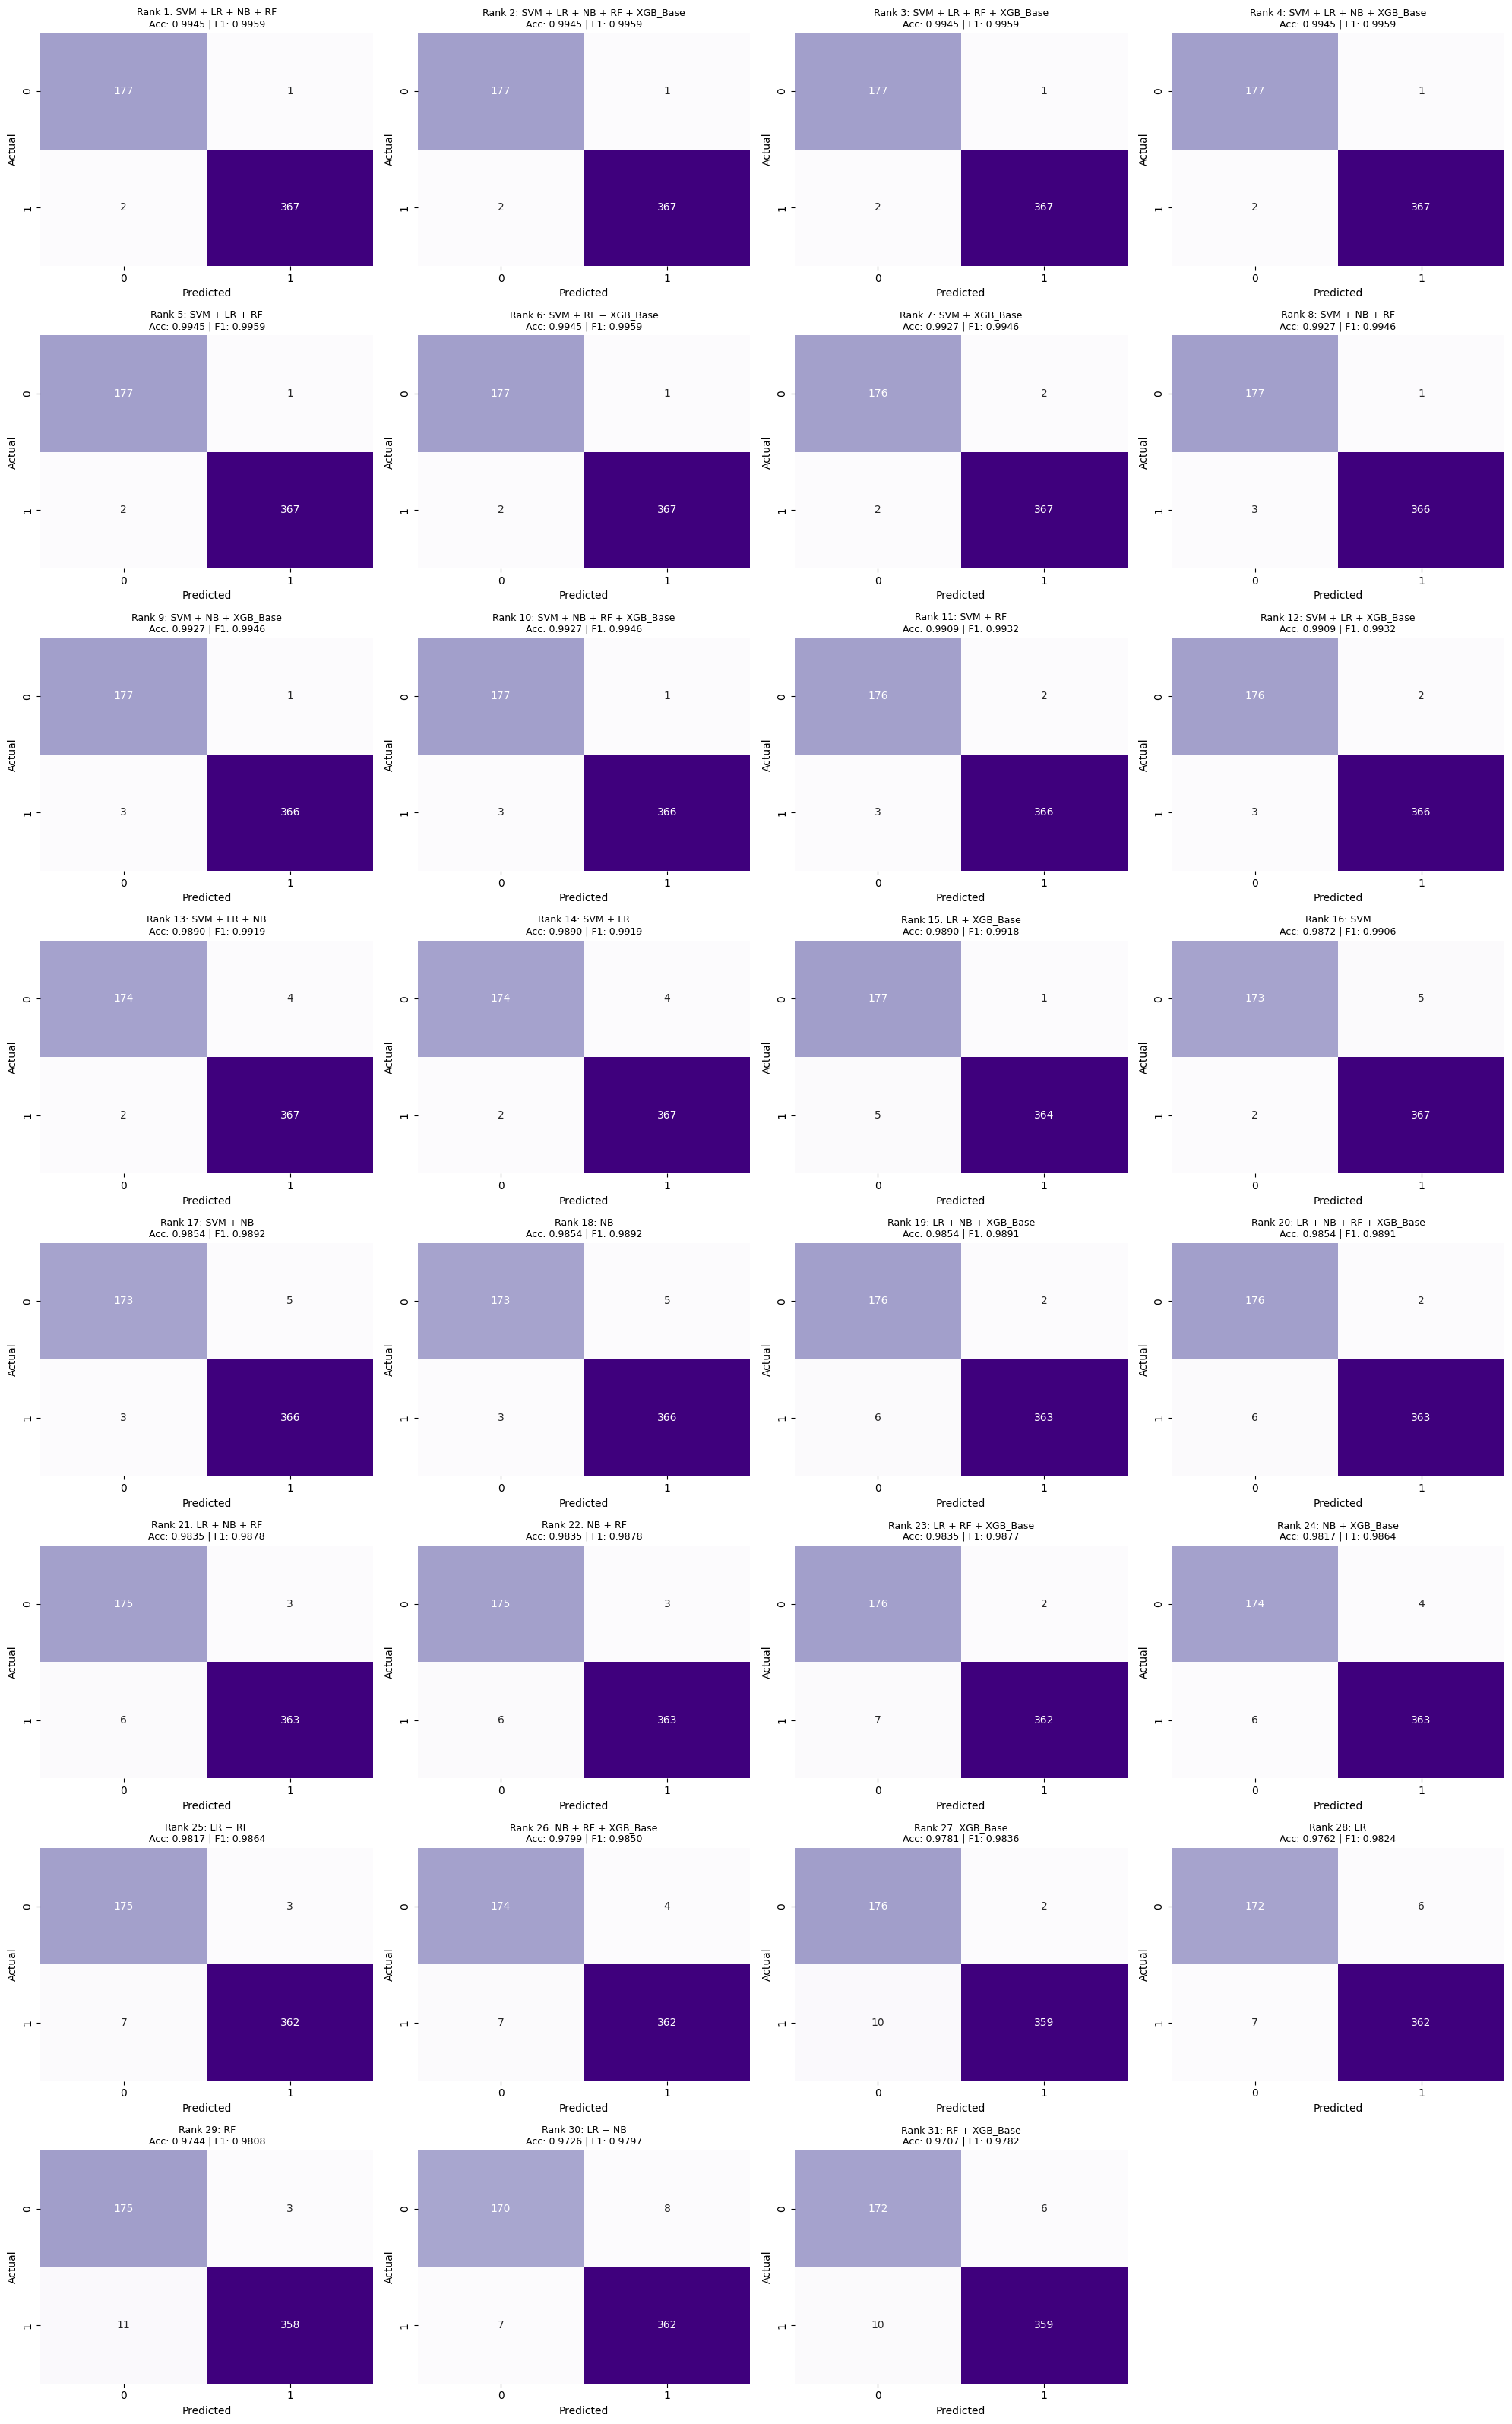

In [82]:
from src.evaluation.metrics import plot_all_ensemble_matrices

# 1. Re-run the ensemble with our new tuple-return setup
stacked_results_df, train_probs, test_probs = evaluate_all_stacked_combinations(
    base_models_config, y_train, y_test
)

# 2. Render the giant master evaluation grid layout
plot_all_ensemble_matrices(
    stacked_results_df, train_probs, test_probs, y_train, y_test)

## **8. Production Artifact Export & Model Serialization**

With the optimal architecture identified and validated, we move to the final stage: **Persistence**. In this step, we retrain the champion configuration on the full training dataset and serialize the resulting models into production-ready artifacts. By exporting these models as compressed `joblib` files, we ensure that our web interface can load the exact decision-making engine validated during our experimental phase, maintaining consistency between the training environment and the production deployment.

In [83]:
from src.models.ensemble import train_and_save_champion

# Train the absolute winner on your out-of-fold states and pickle it
winning_base_models = train_and_save_champion(
    stacked_results_df, train_probs, test_probs, y_train
)

print("\n🚀 Production pipeline artifacts successfully exported and secured!")
print(
    f"To deploy, the web application will need to load: {winning_base_models}")


🏆 Champion Combination Identified: SVM + LR + NB + RF
🥇 Validation F1-Score: 0.9959
🏋️ Freezing final meta-classifier parameters...
📦 Success! Champion ensemble model pickled directly to: saved_models/champion_ensemble.pkl

🚀 Production pipeline artifacts successfully exported and secured!
To deploy, the web application will need to load: ['SVM', 'LR', 'NB', 'RF']


In [84]:
import joblib
import os
import numpy as np
from xgboost import XGBClassifier

# 1. Ensure the export folder exists
os.makedirs("saved_models", exist_ok=True)

# 2. Extract the absolute highest-performing combination from your results table
champion_row = stacked_results_df.iloc[0]
champion_combo_name = champion_row["Combination"]
best_combo = champion_combo_name.split(" + ")

print(
    f"🥇 Automatically identified champion combination: {champion_combo_name}")
print(f"📈 Top F1-Score: {champion_row['F1-Score']:.4f}")

# 3. Re-stack the exact subset of out-of-fold training probabilities that won
meta_X_train_best = np.column_stack([
    train_probs[m] for m in best_combo
])

# 4. Instantiate and fit your missing production meta-classifier variable
print("🏋️ Training production meta-classifier...")
best_meta_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
best_meta_model.fit(meta_X_train_best, y_train)

# 5. Export the 5 fitted base models from your notebook dictionary
print("📦 Pickling base models...")
joblib.dump(base_models_config["SVM"][0], "saved_models/base_svm.pkl")
joblib.dump(base_models_config["LR"][0], "saved_models/base_lr.pkl")
joblib.dump(base_models_config["NB"][0], "saved_models/base_nb.pkl")
joblib.dump(base_models_config["RF"][0], "saved_models/base_rf.pkl")
joblib.dump(base_models_config["XGB_Base"][0], "saved_models/base_xgb.pkl")

# 6. Export the newly created champion meta-classifier
joblib.dump(best_meta_model, "saved_models/champion_ensemble.pkl")

print("\n🎉 SUCCESS! All 5 base models and your champion meta-classifier are secured in 'saved_models/'!")

🥇 Automatically identified champion combination: SVM + LR + NB + RF
📈 Top F1-Score: 0.9959
🏋️ Training production meta-classifier...
📦 Pickling base models...

🎉 SUCCESS! All 5 base models and your champion meta-classifier are secured in 'saved_models/'!
